# 05_1. Постобработка шума: reduce_outliers

**Вход:** обученная модель Config1 из `05_hyperparams.ipynb`  
**Цель:** применить цепочку стратегий `reduce_outliers` и измерить эффект  
**Методология:** двухэтапная схема Grootendorst - сначала оптимизация гиперпараметров, затем постобработка шума как отдельный шаг  

Стратегии (цепочка, как рекомендует автор BERTopic):
1. `c-tf-idf` - быстрая, не требует embeddings
2. `embeddings` - cosine similarity между doc embedding и topic centroid

После каждого шага пересчитываем метрики и сравниваем с исходным Config1.

## 0. Импорты и пути

In [3]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import hdbscan.validity as dbcv_module

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
RESULTS_DIR = Path("results/noise_filtering")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CONFIGS = {
    "best_config": {
        "model_path": Path("results/hyperparams/bertopic_top1"),
        "topics_path": DATA_DIR / "topics_best_config.npy",
        "topics_idx_path": DATA_DIR / "topics_best_config_idx.npy",
        "dataset_path": DATA_DIR / "posts_preprocessed.parquet",
        "embeddings_candidates": [
            DATA_DIR / "embeddings_USER-bge-m3.npy",
            DATA_DIR / "embeddings_USER-bge-m3_300k.npy",
        ],
    },
}

CONFIG_NAME = "best_config"

# Sampling options
SAMPLE_SIZE = None
SAMPLE_STRATEGY = "stratified"  # "random" or "stratified"
STRATIFY_COL = "channel_name"
RANDOM_STATE = 42


def patch_pynndescent() -> bool:
    try:
        from pynndescent import NNDescent
    except Exception:
        return False
    if getattr(NNDescent, "__patched_setstate__", False):
        return True
    original_setstate = NNDescent.__setstate__

    def _patched_setstate(self, d):
        defaults = {
            "quantization": None,
            "_min_distance": 0.0,
            "parallel_batch_queries": False,
        }
        for key, val in defaults.items():
            if key not in d:
                d[key] = val
        original_setstate(self, d)

    NNDescent.__setstate__ = _patched_setstate
    NNDescent.__patched_setstate__ = True
    return True


patch_pynndescent()

print("Импорты готовы")

Импорты готовы


## 1. Загрузка модели и данных из nb05

Если задан `N_DOCS`, метрики (включая DBCV) считаются на подмножестве - это приближенная оценка для выбранной выборки.

In [4]:
if CONFIG_NAME not in CONFIGS:
    raise KeyError(f"Неизвестный CONFIG_NAME: {CONFIG_NAME}")

cfg = CONFIGS[CONFIG_NAME]

DATASET_PATH = cfg.get("dataset_path", DATA_DIR / "posts_preprocessed.parquet")
MODEL_PATH = cfg.get("model_path")
TOPICS_PATH = cfg.get("topics_path")
TOPICS_IDX_PATH = cfg.get("topics_idx_path")
EMBEDDINGS_CANDIDATES = cfg.get("embeddings_candidates", [])

if MODEL_PATH is None or TOPICS_PATH is None:
    raise ValueError("CONFIGS должен содержать model_path и topics_path")

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Не найден файл: {DATASET_PATH}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Не найдена модель: {MODEL_PATH}")
if not TOPICS_PATH.exists():
    raise FileNotFoundError(f"Не найден файл: {TOPICS_PATH}")
if TOPICS_IDX_PATH is not None and not TOPICS_IDX_PATH.exists():
    print(f"[!] topics_idx_path не найден: {TOPICS_IDX_PATH} -> используем range")


def load_embeddings(candidates, df_len):
    existing = [Path(p) for p in candidates if Path(p).exists()]
    if not existing:
        raise FileNotFoundError("Не найдены файлы эмбеддингов в embeddings_candidates")
    chosen = None
    for p in existing:
        arr = np.load(p)
        if len(arr) == df_len:
            chosen = (p, arr)
            break
        if chosen is None:
            chosen = (p, arr)
    path, arr = chosen
    if len(arr) != df_len:
        raise ValueError(
            f"Размеры не совпадают: df={df_len}, embeddings={len(arr)} (файл: {path})"
        )
    return arr, path


df = pd.read_parquet(DATASET_PATH)
embeddings, embeddings_path = load_embeddings(EMBEDDINGS_CANDIDATES, len(df))

topics_full = np.load(TOPICS_PATH).tolist()
if TOPICS_IDX_PATH is not None and TOPICS_IDX_PATH.exists():
    saved_idx = np.asarray(np.load(TOPICS_IDX_PATH))
else:
    saved_idx = np.arange(len(topics_full))

if len(saved_idx) != len(topics_full):
    raise ValueError(
        f"Размеры не совпадают: topics={len(topics_full)}, idx={len(saved_idx)}"
    )

if len(saved_idx) > len(df):
    raise ValueError(f"saved_idx выходит за пределы датасета: {len(df)}")

df_available = df.iloc[saved_idx].reset_index(drop=False)

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df_available):
    if SAMPLE_STRATEGY == "stratified":
        if STRATIFY_COL not in df_available.columns:
            raise KeyError(f"Колонка для стратификации не найдена: {STRATIFY_COL}")
        sample_pos = (
            df_available.groupby(STRATIFY_COL, group_keys=False)
            .apply(
                lambda g: g.sample(
                    n=min(
                        len(g),
                        int(np.ceil(SAMPLE_SIZE * len(g) / len(df_available))),
                    ),
                    random_state=RANDOM_STATE,
                )
            )
            .index
        )
        if len(sample_pos) > SAMPLE_SIZE:
            rng = np.random.default_rng(RANDOM_STATE)
            sample_pos = rng.choice(sample_pos, size=SAMPLE_SIZE, replace=False)
        sample_pos = np.asarray(sample_pos)
    elif SAMPLE_STRATEGY == "random":
        rng = np.random.default_rng(RANDOM_STATE)
        sample_pos = rng.choice(len(df_available), size=SAMPLE_SIZE, replace=False)
    else:
        raise ValueError("SAMPLE_STRATEGY должен быть 'random' или 'stratified'")
    sample_pos.sort()
else:
    sample_pos = np.arange(len(df_available))

actual_idx = saved_idx[sample_pos]
topics_orig = [topics_full[i] for i in sample_pos]

df = df.iloc[actual_idx].reset_index(drop=True)
embeddings = embeddings[actual_idx]

docs_lemm = df["text_lemm"].tolist()
docs_clean = df["text_clean"].tolist()

patch_pynndescent()
try:
    topic_model = BERTopic.load(str(MODEL_PATH))
except AttributeError:
    patch_pynndescent()
    topic_model = BERTopic.load(str(MODEL_PATH))

assert len(topics_orig) == len(df) == len(embeddings)
print(f"Конфиг: {CONFIG_NAME}")
print(f"Датасет: {DATASET_PATH}")
print(f"Эмбеддинги: {embeddings_path}")
print(f"Работаем с {len(df):,} документами")
print(f"Эмбеддинги: {embeddings.shape}")
print(f"Тем в модели: {len(topic_model.get_topics()) - 1}")
print(f"Noise (исходный): {(np.array(topics_orig) == -1).mean():.3f}")

Конфиг: best_config
Датасет: data\posts_preprocessed.parquet
Эмбеддинги: data\embeddings_USER-bge-m3_300k.npy
Работаем с 300,000 документами
Эмбеддинги: (300000, 1024)
Тем в модели: 257
Noise (исходный): 0.490


## 2. Базовые метрики Config1 (до постобработки)

Фиксируем точку отсчёта - всё то, что уже есть в nb05.

In [ ]:
COHERENCE_SAMPLE_SIZE = 30_000
COHERENCE_TOP_WORDS = 10


def compute_metrics(model, topics, docs, label=""):
    """DBCV, C_V coherence, Topic Diversity, Noise Ratio, Classified Ratio."""
    topics_arr = np.array(topics)
    noise_ratio = float((topics_arr == -1).mean())
    classified_ratio = 1.0 - noise_ratio
    n_topics = len([t for t in model.get_topics() if t != -1])

    # DBCV с субсэмплингом
    reduced = model.umap_model.embedding_
    if reduced is None:
        reduced = None
    elif reduced.shape[0] != len(topics_arr):
        if "actual_idx" in globals() and len(actual_idx) == len(topics_arr):
            reduced = reduced[actual_idx]
        else:
            reduced = None

    mask = topics_arr != -1
    if reduced is None or mask.sum() < 2 or len(np.unique(topics_arr[mask])) < 2:
        dbcv = float("nan")
    else:
        rng = np.random.default_rng(RANDOM_STATE)
        keep_idx = []
        for cid in np.unique(topics_arr[mask]):
            idx = np.where(topics_arr == cid)[0]
            if len(idx) > 500:
                idx = rng.choice(idx, size=500, replace=False)
            keep_idx.extend(idx.tolist())
        keep_idx = np.array(keep_idx)
        if keep_idx.size == 0:
            dbcv = float("nan")
        else:
            try:
                dbcv = float(
                    dbcv_module.validity_index(
                        reduced[keep_idx].astype(np.float64), topics_arr[keep_idx]
                    )
                )
            except Exception as e:
                print(f"  DBCV ошибка: {e}")
                dbcv = float("nan")

    # C_V coherence (по лемматизированным текстам)
    topic_words_list = [
        [w for w, _ in model.get_topic(t)[:COHERENCE_TOP_WORDS]]
        for t in model.get_topics()
        if t != -1
    ]
    tokenized = [d.split() for d in docs]
    if COHERENCE_SAMPLE_SIZE is not None and len(tokenized) > COHERENCE_SAMPLE_SIZE:
        rng = np.random.default_rng(RANDOM_STATE)
        sample_idx = rng.choice(len(tokenized), size=COHERENCE_SAMPLE_SIZE, replace=False)
        tokenized = [tokenized[i] for i in sample_idx]
    dictionary = Dictionary(tokenized)
    valid_tokens = set(dictionary.token2id.keys())
    filtered = [[w for w in wl if w in valid_tokens] for wl in topic_words_list]
    filtered = [wl for wl in filtered if len(wl) >= 2]
    try:
        cm = CoherenceModel(
            topics=filtered,
            texts=tokenized,
            dictionary=dictionary,
            coherence="c_v",
        )
        cv = float(cm.get_coherence())
    except Exception as e:
        print(f"  C_V ошибка: {e}")
        cv = float("nan")

    # Topic Diversity
    all_words = [w for wl in topic_words_list for w in wl]
    diversity = len(set(all_words)) / len(all_words) if all_words else 0.0

    result = {
        "label": label,
        "n_topics": n_topics,
        "noise_ratio": round(noise_ratio, 4),
        "classified_ratio": round(classified_ratio, 4),
        "dbcv": round(dbcv, 4),
        "cv_coherence": round(cv, 4),
        "topic_diversity": round(diversity, 4),
    }
    print(f"\n[{label}]")
    for k, v in result.items():
        if k != "label":
            print(f"  {k:20s}: {v}")
    return result


metrics_before = compute_metrics(topic_model, topics_orig, docs_lemm, label=CONFIG_NAME)

## 3. Шаг 1: reduce_outliers стратегия c-tf-idf

Быстрая стратегия - сравнивает c-TF-IDF вектор документа с c-TF-IDF представлениями тем.  
Не требует embeddings, работает за секунды.

`threshold=0.1` - документ переназначается только если сходство с темой > 0.1.  
Значение подбирается ниже через ablation.

In [ ]:
# Ablation по порогу для стратегии c-tf-idf
thresholds_to_test = [i/100 for i in range(0, 100, 5)]  # 0.0, 0.05, ..., 0.95
ablation_results = []

for thr in thresholds_to_test:
    new_topics_thr = topic_model.reduce_outliers(
        docs_clean, topics_orig,
        strategy='c-tf-idf',
        threshold=thr
    )
    noise = (np.array(new_topics_thr) == -1).mean()
    classified = 1.0 - noise
    ablation_results.append({
        'threshold': thr,
        'noise_ratio': round(noise, 4),
        'classified_ratio': round(classified, 4),
        'reassigned': int((np.array(topics_orig) == -1).sum()) - int((np.array(new_topics_thr) == -1).sum())
    })
    print(f'threshold={thr:.2f} -> noise={noise:.3f}, classified={classified:.3f}')

ablation_df = pd.DataFrame(ablation_results)
print('\nAblation c-tf-idf:')
print(ablation_df.to_string(index=False))

  threshold=0.00 -> noise=0.007, classified=0.993
  threshold=0.05 -> noise=0.092, classified=0.908
  threshold=0.10 -> noise=0.271, classified=0.729
  threshold=0.15 -> noise=0.369, classified=0.631
  threshold=0.20 -> noise=0.419, classified=0.581
  threshold=0.25 -> noise=0.447, classified=0.553
  threshold=0.30 -> noise=0.465, classified=0.535
  threshold=0.35 -> noise=0.475, classified=0.525
  threshold=0.40 -> noise=0.480, classified=0.520
  threshold=0.45 -> noise=0.484, classified=0.516
  threshold=0.50 -> noise=0.487, classified=0.513
  threshold=0.55 -> noise=0.488, classified=0.512
  threshold=0.60 -> noise=0.489, classified=0.511
  threshold=0.65 -> noise=0.490, classified=0.510
  threshold=0.70 -> noise=0.490, classified=0.510
  threshold=0.75 -> noise=0.490, classified=0.510
  threshold=0.80 -> noise=0.490, classified=0.510
  threshold=0.85 -> noise=0.490, classified=0.510
  threshold=0.90 -> noise=0.490, classified=0.510
  threshold=0.95 -> noise=0.490, classified=0.510


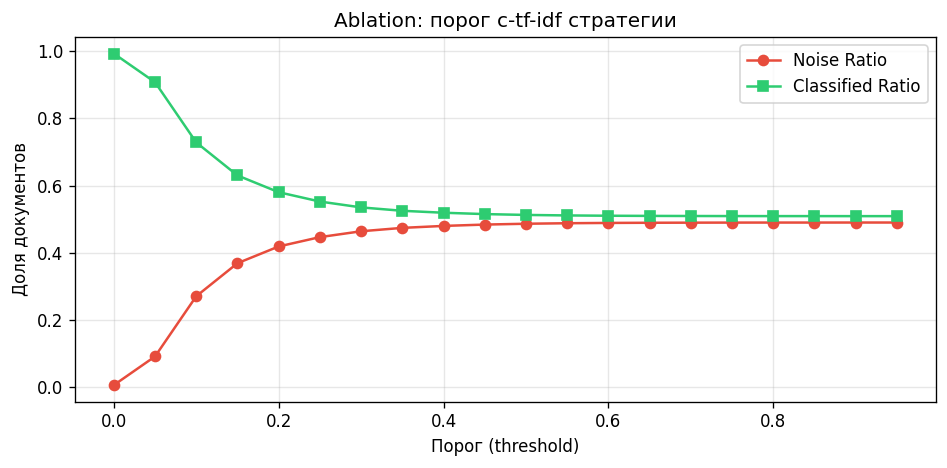

In [ ]:
# Визуализация ablation
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ablation_df['threshold'], ablation_df['noise_ratio'], 'o-', label='Noise Ratio', color='#e74c3c')
ax.plot(ablation_df['threshold'], ablation_df['classified_ratio'], 's-', label='Classified Ratio', color='#2ecc71')
ax.set_xlabel('Порог (threshold)')
ax.set_ylabel('Доля документов')
ax.set_title('Ablation: порог c-tf-idf стратегии')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ablation_ctfidf_threshold.png')
plt.show()

In [ ]:
THRESHOLD_CTFIDF = 0.4

topics_after_ctfidf = topic_model.reduce_outliers(
    docs_clean, topics_orig,
    strategy='c-tf-idf',
    threshold=THRESHOLD_CTFIDF
)

reassigned_step1 = (
    (np.array(topics_orig) == -1).sum() -
    (np.array(topics_after_ctfidf) == -1).sum()
)
print(f'Переназначено на шаге 1 (c-tf-idf): {reassigned_step1:,} документов')
print(f'Noise после шага 1: {(np.array(topics_after_ctfidf) == -1).mean():.3f}')

Переназначено на шаге 1 (c-tf-idf): 502 документов
Noise после шага 1: 0.480


## 4. Шаг 2: reduce_outliers стратегия embeddings

Для оставшихся outliers - cosine similarity между эмбеддингом документа и центроидом темы.  
Работает на предвычисленных эмбеддингах из nb03, переобучения не требует.

In [ ]:
# Ablation по порогу для стратегии embeddings
ablation_emb = []

for thr in thresholds_to_test:
    new_topics_thr = topic_model.reduce_outliers(
        docs_clean, topics_after_ctfidf,
        strategy='embeddings',
        embeddings=embeddings,
        threshold=thr
    )
    noise = (np.array(new_topics_thr) == -1).mean()
    ablation_emb.append({
        'threshold': thr,
        'noise_ratio': round(noise, 4),
        'classified_ratio': round(1 - noise, 4),
    })
    print(f'  threshold={thr:.2f} -> noise={noise:.3f}')

ablation_emb_df = pd.DataFrame(ablation_emb)
print('\nAblation embeddings:')
print(ablation_emb_df.to_string(index=False))

  threshold=0.00 -> noise=0.000
  threshold=0.05 -> noise=0.000
  threshold=0.10 -> noise=0.000
  threshold=0.15 -> noise=0.000
  threshold=0.20 -> noise=0.000
  threshold=0.25 -> noise=0.000
  threshold=0.30 -> noise=0.000
  threshold=0.35 -> noise=0.000
  threshold=0.40 -> noise=0.000
  threshold=0.45 -> noise=0.001
  threshold=0.50 -> noise=0.008
  threshold=0.55 -> noise=0.047
  threshold=0.60 -> noise=0.154
  threshold=0.65 -> noise=0.303
  threshold=0.70 -> noise=0.413
  threshold=0.75 -> noise=0.462
  threshold=0.80 -> noise=0.477
  threshold=0.85 -> noise=0.480
  threshold=0.90 -> noise=0.480
  threshold=0.95 -> noise=0.480

Ablation embeddings:
 threshold  noise_ratio  classified_ratio
      0.00       0.0000            1.0000
      0.05       0.0000            1.0000
      0.10       0.0000            1.0000
      0.15       0.0000            1.0000
      0.20       0.0000            1.0000
      0.25       0.0000            1.0000
      0.30       0.0000            1.0000
  

In [ ]:
THRESHOLD_EMB = 0.6

topics_after_emb = topic_model.reduce_outliers(
    docs_clean, topics_after_ctfidf,
    strategy='embeddings',
    embeddings=embeddings,
    threshold=THRESHOLD_EMB
)

reassigned_step2 = (
    (np.array(topics_after_ctfidf) == -1).sum() -
    (np.array(topics_after_emb) == -1).sum()
)
print(f'Переназначено на шаге 2 (embeddings): {reassigned_step2:,} документов')
print(f'Noise после шага 2: {(np.array(topics_after_emb) == -1).mean():.3f}')

Переназначено на шаге 2 (embeddings): 16,297 документов
Noise после шага 2: 0.154


## 5. update_topics - пересчёт c-TF-IDF репрезентаций

Обязательный шаг после переназначения: без него топ-слова тем остаются от старого распределения.  
> **Важно:** после `update_topics` metric DBCV теряет смысл как метрика плотностной кластеризации,  
> поскольку UMAP-проекция не пересчитывается. Основные метрики эффекта - C_V, Diversity, Classified Ratio.

In [ ]:
topic_model.update_topics(docs_lemm, topics=topics_after_emb)
print('update_topics выполнен')
print(f'Тем в модели после update: {len(topic_model.get_topics()) - 1}')

2026-05-03 13:26:41,273 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


update_topics выполнен
Тем в модели после update: 257


## 6. Метрики после постобработки

In [ ]:
metrics_after = compute_metrics(
    topic_model, topics_after_emb, docs_lemm,
    label='best_config + reduce_outliers'
)


[best_config + reduce_outliers]
  n_topics            : 257
  noise_ratio         : 0.1545
  classified_ratio    : 0.8455
  dbcv                : -0.9093
  cv_coherence        : 0.7287
  topic_diversity     : 0.6821


## 7. Сравнительная таблица до / после

In [ ]:
before_label = metrics_before["label"]
after_label = metrics_after["label"]

comparison = pd.DataFrame([metrics_before, metrics_after])
comparison = comparison.set_index("label")

delta = comparison.loc[after_label] - comparison.loc[before_label]
delta.name = "Δ"

comparison_with_delta = pd.concat([comparison, delta.to_frame().T])
print("\n=== Сравнение метрик до / после reduce_outliers ===")
print(comparison_with_delta.to_string())

comparison_with_delta.to_csv(RESULTS_DIR / "metrics_comparison.csv")
print("\nСохранено: results/noise_filtering/metrics_comparison.csv")


=== Сравнение метрик до / после reduce_outliers ===
                               n_topics  noise_ratio  classified_ratio    dbcv  cv_coherence  topic_diversity
best_config                       257.0       0.4905            0.5095  0.5861        0.7405           0.7673
best_config + reduce_outliers     257.0       0.1545            0.8455 -0.9093        0.7287           0.6821
Δ                                   0.0      -0.3360            0.3360 -1.4954       -0.0118          -0.0852

Сохранено: results/noise_filtering/metrics_comparison.csv


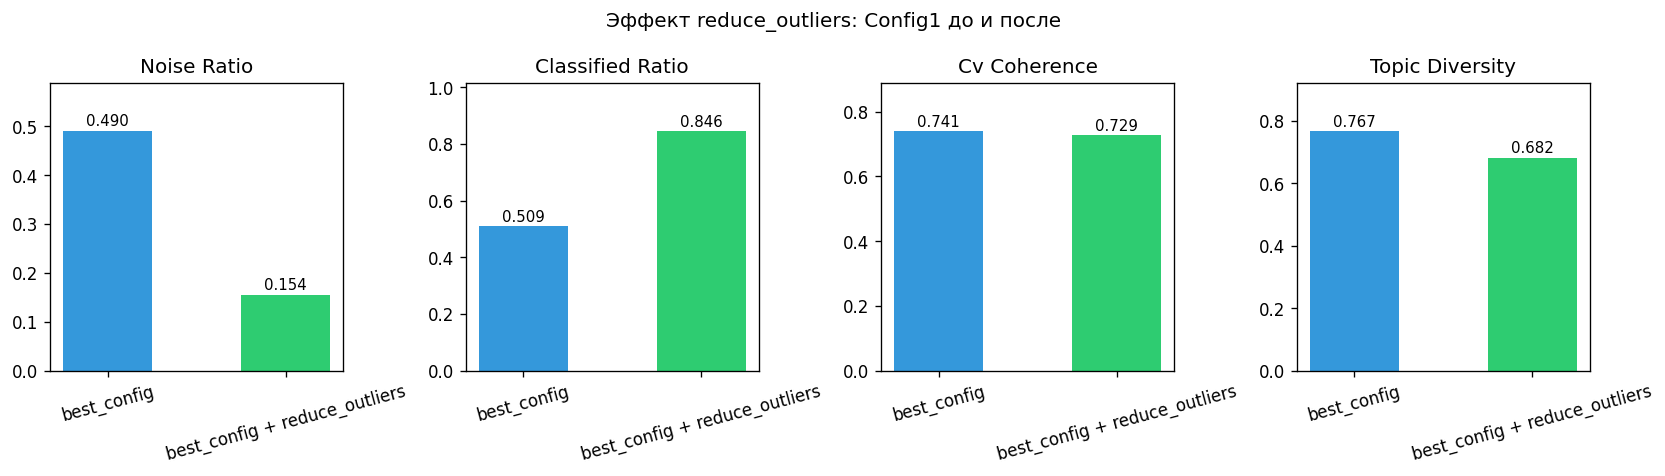

In [ ]:
plot_metrics = ["noise_ratio", "classified_ratio", "cv_coherence", "topic_diversity"]
labels_plot = [
    metrics_before.get("label", "Config1 (до)"),
    metrics_after.get("label", "Config1 + reduce_outliers"),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
colors = ["#3498db", "#2ecc71"]

for ax, metric in zip(axes, plot_metrics):
    vals = [metrics_before[metric], metrics_after[metric]]
    bars = ax.bar(labels_plot, vals, color=colors, width=0.5)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_ylim(0, max(vals) * 1.2)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Эффект reduce_outliers: Config1 до и после", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "metrics_before_after.png", bbox_inches="tight")
plt.show()

## 8. Анализ переназначенных документов

Sanity check: смотрим куда ушли бывшие outliers - равномерно по темам или в одну-две.

In [ ]:
# Маска документов, которые были -1 и стали не -1
orig_arr   = np.array(topics_orig)
after_arr  = np.array(topics_after_emb)

reassigned_mask = (orig_arr == -1) & (after_arr != -1)
reassigned_topics = after_arr[reassigned_mask]

topic_counts = pd.Series(reassigned_topics).value_counts()
print(f'Всего переназначено: {reassigned_mask.sum():,}')
print(f'Распределено по {len(topic_counts)} темам')
print('\nТоп-10 тем по числу принятых outliers:')
print(topic_counts.head(10).to_string())

# Проверка: нет ли одной доминирующей темы (признак слишком жадной стратегии)
top1_share = topic_counts.iloc[0] / reassigned_mask.sum()
print(f'\nДоля топ-1 темы: {top1_share:.2%}')
if top1_share > 0.3:
    print('[!]\tБолее 30% outliers ушли в одну тему - стратегия может быть слишком жадной')
else:
    print('[+]\tРаспределение равномерное')

Всего переназначено: 16,799
Распределено по 257 темам

Топ-10 тем по числу принятых outliers:
5      445
20     404
156    265
13     252
6      229
152    228
194    205
18     200
35     199
248    195

Доля топ-1 темы: 2.65%
[+]	Распределение равномерное


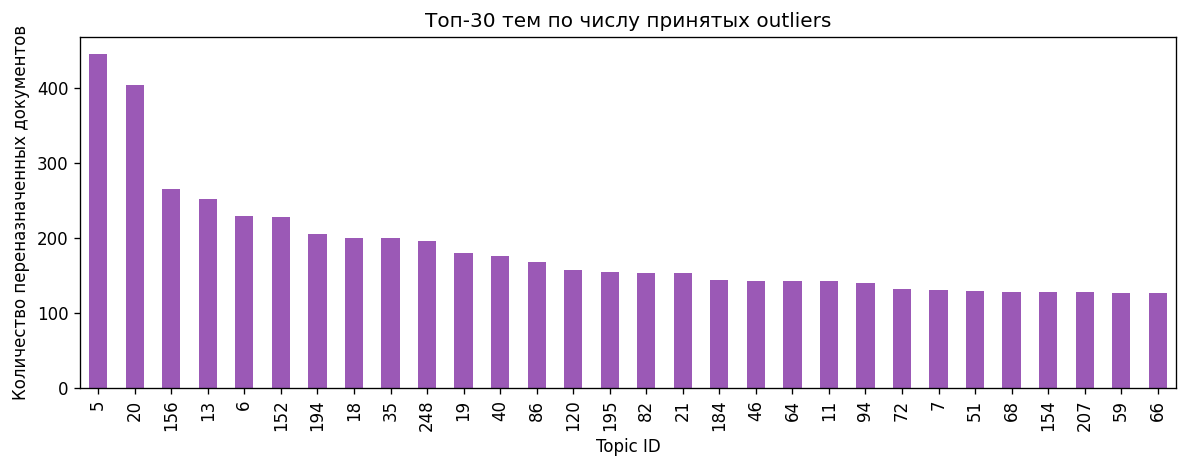

In [ ]:
# Распределение переназначенных outliers по темам
fig, ax = plt.subplots(figsize=(10, 4))
topic_counts.head(30).plot(kind='bar', ax=ax, color='#9b59b6')
ax.set_title('Топ-30 тем по числу принятых outliers')
ax.set_xlabel('Topic ID')
ax.set_ylabel('Количество переназначенных документов')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'reassigned_distribution.png', bbox_inches='tight')
plt.show()

## 9. Примеры переназначенных документов

Ручная проверка качества переназначения на 10 случайных примерах.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(
    np.where(reassigned_mask)[0],
    size=min(10, reassigned_mask.sum()),
    replace=False,
)

print("=== 10 случайных переназначенных документов (до -> после) ===")
for i, idx in enumerate(sample_idx):
    old_topic = orig_arr[idx]
    new_topic = after_arr[idx]

    if old_topic == -1:
        old_words = "Noise"
    else:
        old_words = ", ".join([w for w, _ in topic_model.get_topic(old_topic)[:5]])

    if new_topic == -1:
        new_words = "Noise"
    else:
        new_words = ", ".join([w for w, _ in topic_model.get_topic(new_topic)[:5]])

    doc_preview = docs_clean[idx][:150].replace("\n", " ")

    print(f"\n[{i+1}] {old_topic} ({old_words}) -> {new_topic} ({new_words})")
    print(f"    {doc_preview}...")

=== 10 случайных переназначенных документов (до -> после) ===

[1] -1 (Noise) -> 200 (беженец, донбасс, лнр, размещение, ростовский)
    Бойцы ЛНР эвакуируют мирных жителей из Рубежного. Видео: РИА "Новости" @tv360...

[2] -1 (Noise) -> 252 (новогодний, салют, фейерверк, бессмертный, отменить)
    В Самаре отменили очное шествие Бессмертного полка в 2023 году В этом году в России, и, в частности, в Самаре, отказались от проведения шествия «Бессм...

[3] -1 (Noise) -> 67 (певица, муж, актриса, артистка, брак)
    Известная блогер из Волгограда Аня Покров приехала на малую родину поздравить маму ( с днем рождения. Как сообщает V102.RU, главным подарком в знамена...

[4] -1 (Noise) -> 5 (путин, владимир, президент, россия, государство)
    ▶️ Владимир Путин по видео-конференц-связи участвует в церемонии передачи партии нового общественного транспорта некоторым регионам страны. Парк общес...

[5] -1 (Noise) -> 101 (паводок, орск, вода, оренбургский, подтопить)
    ️ Сотрудники МЧС России у

## 10. Сохранение результатов

In [ ]:
# Сохраняем переназначенные топики для использования в nb06
np.save(DATA_DIR / 'topics_best_config_reduced.npy', np.array(topics_after_emb))

# Сохраняем финальную модель с обновлёнными репрезентациями
model_out = RESULTS_DIR / 'bertopic_best_config_reduced'
topic_model.save(str(model_out))

# Сохраняем итоговые метрики
summary = {
    'thresholds': {
        'c_tf_idf': THRESHOLD_CTFIDF,
        'embeddings': THRESHOLD_EMB,
    },
    'reassigned_step1_ctfidf': int(reassigned_step1),
    'reassigned_step2_embeddings': int(reassigned_step2),
    'reassigned_total': int(reassigned_step1 + reassigned_step2),
    'metrics_before': metrics_before,
    'metrics_after': metrics_after,
}
with open(RESULTS_DIR / 'noise_filtering_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('Сохранено:')
print('\tdata/topics_best_config_reduced.npy')
print('\tresults/noise_filtering/bertopic_best_config_reduced/')
print('\tresults/noise_filtering/noise_filtering_summary.json')
print('\tresults/noise_filtering/metrics_comparison.csv')

2026-05-03 13:33:58,119 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Сохранено:
	data/topics_config1_reduced.npy
	results/noise_filtering/bertopic_config1_reduced/
	results/noise_filtering/noise_filtering_summary.json
	results/noise_filtering/metrics_comparison.csv


## 11. Итог

**Ключевые числа для таблицы в ВКР (раздел 2.3.X):**

| Конфигурация | Тем | Noise↓ | Classified↑ | DBCV↑* | C_V↑ | Diversity |
|---|---|---|---|---|---|---|
| Config1 (до) | - | - | - | - | - | - |
| Config1 + reduce_outliers | - | - | - | n/a* | - | - |

*DBCV после `update_topics` не пересчитывается корректно, поскольку UMAP-проекция остаётся от исходной кластеризации - это ожидаемое ограничение метрики, а не деградация модели.

**Методологическая заметка:**  
Разделение на два этапа (оптимизация гиперпараметров в nb05 -> постобработка шума в nb05_1)  
соответствует рекомендованной схеме Grootendorst: гиперпараметры оптимизируются  
по качеству кластеризации (DBCV), а `reduce_outliers` применяется как отдельный downstream-шаг,  
не влияющий на структуру HDBSCAN-дерева.